In [4]:
# Importing Data:
from google.colab import files
uploaded = files.upload()

Saving train_NYC_inspection.parquet to train_NYC_inspection.parquet


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# loading parquet training dataset
df = pd.read_parquet("train_NYC_inspection.parquet")

df.head()

,CUISINE DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,INSPECTION DATE,BUILDING,STREET,GRADE
0,Chinese,Queens,11354.0,40.759778,-73.829235,2024-08-05,136-20,ROOSEVELT AVENUE,A
1,Coffee/Tea,Queens,11362.0,40.769834,-73.736180,2025-10-31,25201,NORTHERN BLVD,A
2,Japanese,Manhattan,10036.0,40.759161,-73.990369,2025-05-02,354,WEST 44 STREET,B
3,Pizza,Queens,11372.0,40.756245,-73.878681,2025-04-15,8906,NORTHERN BLVD,C
4,Chicken,Queens,11432.0,40.708211,-73.803110,2024-02-29,87-44,PARSONS BOULEVARD,None


In [6]:
np.random.seed(42)
torch.manual_seed(42)

In [7]:
# data cleaning

# drop rows with missing target values
df = df.dropna(subset=["GRADE"])

# define features and target
target_col = "GRADE"
y = df[target_col].astype(str)

# drop non-essential columns for feature engineering
X = df.drop(columns=[target_col, "INSPECTION DATE", "BUILDING", "STREET"])

# first keep all non-dropped columns
print("Columns before encoding:", list(X.columns))

# encode categorical features
cuisine_encoder = LabelEncoder()
X["CUISINE_ENCODED"] = cuisine_encoder.fit_transform(X["CUISINE DESCRIPTION"].astype(str))
X = X.drop(columns=["CUISINE DESCRIPTION"])

boro_encoder = LabelEncoder()
X["BORO_ENCODED"] = boro_encoder.fit_transform(X["BORO"].astype(str))
X = X.drop(columns=["BORO"])

# keep only numeric features
X = X.select_dtypes(include=[np.number]).copy()

# replace missing values with median
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# remove rows where target has missing values (already dropped above, but keep consistent)
valid_idx = y.notna()
X = X[valid_idx].values.astype(np.float64)
y = y[valid_idx].values.astype(str)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Columns before encoding: ['CUISINE DESCRIPTION', 'BORO', 'ZIPCODE', 'Latitude', 'Longitude']
Feature matrix shape: (68423, 5)
Target shape: (68423,)


In [8]:
# define neural network architecture

class GradeNeuralNetwork(nn.Module):

    """
    fully connected neural network for GRADE classification

    - input layer: matches number of features
    - 3 hidden layers with batch normalization and dropout
    - output layer: one logit per grade class
    """

    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64,
                 hidden_dim3=32, dropout_rate=0.3, num_classes=6):
        super(GradeNeuralNetwork, self).__init__()

        # layer 1
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.bn1 = nn.BatchNorm1d(hidden_dim1)
        self.dropout1 = nn.Dropout(dropout_rate)

        # layer 2
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.bn2 = nn.BatchNorm1d(hidden_dim2)
        self.dropout2 = nn.Dropout(dropout_rate)

        # layer 3
        self.fc3 = nn.Linear(hidden_dim2, hidden_dim3)
        self.bn3 = nn.BatchNorm1d(hidden_dim3)
        self.dropout3 = nn.Dropout(dropout_rate)

        # output layer: logits for each class
        self.fc4 = nn.Linear(hidden_dim3, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)

        x = self.fc4(x)  # logits, to be used with CrossEntropyLoss

        return x

In [9]:
def train_neural_network(X_train, y_train, X_val, y_val, model,
                         learning_rate=0.001, epochs=100, batch_size=32):
    """
    train neural network on training data with validation (GRADE classification)

    args:
        X_train, y_train: Training data (features, integer class labels)
        X_val, y_val: Validation data
        model: PyTorch model
        learning_rate: Learning rate for optimizer
        epochs: Number of training epochs
        batch_size: Batch size for training

    returns:
        train_losses: Training loss history
        val_losses: Validation loss history
    """

    # convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.LongTensor(y_train)   # class indices
    X_val_tensor = torch.FloatTensor(X_val)
    y_val_tensor = torch.LongTensor(y_val)

    # create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, drop_last=False)

    # loss function and optimizer (classification)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # training phase
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # validation phase
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_tensor)
            val_loss = criterion(val_logits, y_val_tensor).item()
            val_losses.append(val_loss)

    return train_losses, val_losses

In [10]:
# define hyperparameter combinations to test


# encode target labels once for classification
grade_le = LabelEncoder()
y_encoded = grade_le.fit_transform(y)  # y was string grades

# define hyperparameter combinations to test
param_combinations = [
    {"lr": 0.001, "h1": 128, "h2": 64, "h3": 32, "dropout": 0.3, "batch": 32, "epochs": 50},
    {"lr": 0.001, "h1": 128, "h2": 64, "h3": 32, "dropout": 0.2, "batch": 64, "epochs": 75},
    {"lr": 0.0005, "h1": 128, "h2": 64, "h3": 32, "dropout": 0.3, "batch": 64, "epochs": 75},
]

# setup cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# store results
cv_results = []

print(f"\nTesting {len(param_combinations)} hyperparameter combinations")
print("Cross-validation: 5-Fold KFold\n")

num_classes = len(grade_le.classes_)

for combo_idx, params in enumerate(param_combinations, 1):
    print(f"Combination {combo_idx}/{len(param_combinations)}:")
    print(f"Learning Rate: {params['lr']}, Hidden Dims: {params['h1']}-{params['h2']}-{params['h3']}")
    print(f"Dropout: {params['dropout']}, Batch Size: {params['batch']}, Epochs: {params['epochs']}\n")

    fold_acc = []
    fold_f1 = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X), 1):

        # split data
        X_fold_train = X[train_idx]
        y_fold_train = y_encoded[train_idx]
        X_fold_val = X[val_idx]
        y_fold_val = y_encoded[val_idx]

        # scale features (IMPORTANT: prevent data leakage - fit only on training fold)
        scaler = StandardScaler()
        X_fold_train_scaled = scaler.fit_transform(X_fold_train)
        X_fold_val_scaled = scaler.transform(X_fold_val)

        # initialize model
        model = GradeNeuralNetwork(
            input_dim=X_fold_train_scaled.shape[1],
            hidden_dim1=params["h1"],
            hidden_dim2=params["h2"],
            hidden_dim3=params["h3"],
            dropout_rate=params["dropout"],
            num_classes=num_classes,
        )

        # train model
        train_losses, val_losses = train_neural_network(
            X_fold_train_scaled, y_fold_train,
            X_fold_val_scaled, y_fold_val,
            model,
            learning_rate=params["lr"],
            epochs=params["epochs"],
            batch_size=params["batch"],
        )

        # evaluate on validation fold
        model.eval()
        with torch.no_grad():
            X_val_tensor = torch.FloatTensor(X_fold_val_scaled)
            logits = model(X_val_tensor)
            y_pred_fold = torch.argmax(logits, dim=1).numpy()

        acc = accuracy_score(y_fold_val, y_pred_fold)
        f1 = f1_score(y_fold_val, y_pred_fold, average="macro")

        fold_acc.append(acc)
        fold_f1.append(f1)

        print(f"Fold {fold}: Accuracy={acc:.4f}, Macro F1={f1:.4f}")

    # average across folds
    avg_acc = np.mean(fold_acc)
    avg_f1 = np.mean(fold_f1)

    cv_results.append({
        "params": params,
        "avg_acc": avg_acc,
        "avg_f1": avg_f1,
    })

    print(f"Average: Accuracy={avg_acc:.4f}, Macro F1={avg_f1:.4f}\n")

# find best model (by Macro F1)
best_idx = np.argmax([r["avg_f1"] for r in cv_results])
best_params = cv_results[best_idx]["params"]

print(f"BEST MODEL: Combination #{best_idx + 1}\n")
print(f"Learning Rate: {best_params['lr']}")
print(f"Hidden Dims: {best_params['h1']}-{best_params['h2']}-{best_params['h3']}")
print(f"Dropout: {best_params['dropout']}")
print(f"Batch Size: {best_params['batch']}")
print(f"Epochs: {best_params['epochs']}")
print("\nCross-Validated Performance:")
print(f"Accuracy: {cv_results[best_idx]['avg_acc']:.4f}")
print(f"Macro F1: {cv_results[best_idx]['avg_f1']:.4f}")


Testing 3 hyperparameter combinations
Cross-validation: 5-Fold KFold

Combination 1/3:
Learning Rate: 0.001, Hidden Dims: 128-64-32
Dropout: 0.3, Batch Size: 32, Epochs: 50

Fold 1: Accuracy=0.6287, Macro F1=0.1287
Fold 2: Accuracy=0.6307, Macro F1=0.1289
Fold 3: Accuracy=0.6337, Macro F1=0.1293
Fold 4: Accuracy=0.6294, Macro F1=0.1288
Fold 5: Accuracy=0.6256, Macro F1=0.1283
Average: Accuracy=0.6296, Macro F1=0.1288

Combination 2/3:
Learning Rate: 0.001, Hidden Dims: 128-64-32
Dropout: 0.2, Batch Size: 64, Epochs: 75

Fold 1: Accuracy=0.6287, Macro F1=0.1287
Fold 2: Accuracy=0.6307, Macro F1=0.1289
Fold 3: Accuracy=0.6337, Macro F1=0.1293
Fold 4: Accuracy=0.6294, Macro F1=0.1288
Fold 5: Accuracy=0.6256, Macro F1=0.1283
Average: Accuracy=0.6296, Macro F1=0.1288

Combination 3/3:
Learning Rate: 0.0005, Hidden Dims: 128-64-32
Dropout: 0.3, Batch Size: 64, Epochs: 75

Fold 1: Accuracy=0.6287, Macro F1=0.1287
Fold 2: Accuracy=0.6307, Macro F1=0.1289
Fold 3: Accuracy=0.6337, Macro F1=0.12

HYPERPARAMETER TUNING RESULTS SUMMARY:

 Combination  Learning Rate  Hidden 1  Hidden 2  Hidden 3  Dropout  Batch  Epochs  Avg Accuracy  Avg Macro F1
           1         0.0010       128        64        32      0.3     32      50      0.629627      0.128787
           2         0.0010       128        64        32      0.2     64      75      0.629627      0.128787
           3         0.0005       128        64        32      0.3     64      75      0.629627      0.128787


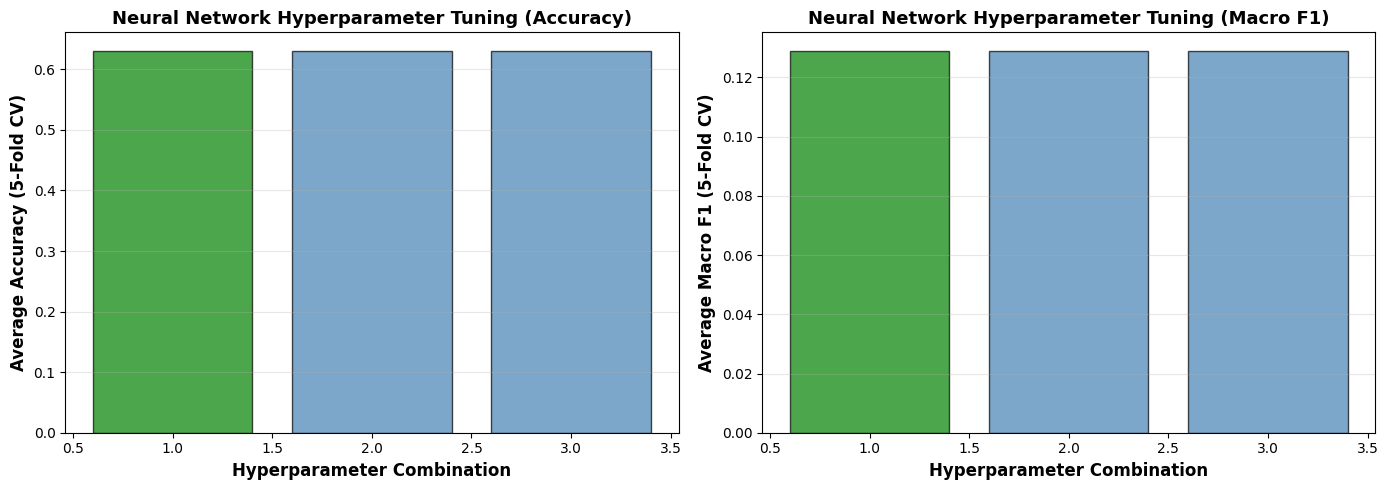

In [11]:
results_df = pd.DataFrame([
    {
        "Combination": i+1,
        "Learning Rate": r["params"]["lr"],
        "Hidden 1": r["params"]["h1"],
        "Hidden 2": r["params"]["h2"],
        "Hidden 3": r["params"]["h3"],
        "Dropout": r["params"]["dropout"],
        "Batch": r["params"]["batch"],
        "Epochs": r["params"]["epochs"],
        "Avg Accuracy": r["avg_acc"],
        "Avg Macro F1": r["avg_f1"],
    }
    for i, r in enumerate(cv_results)
])

print("HYPERPARAMETER TUNING RESULTS SUMMARY:\n")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
acc_values = [r["avg_acc"] for r in cv_results]
colors = ["green" if i == best_idx else "steelblue" for i in range(len(cv_results))]

ax1 = axes[0]
ax1.bar(range(1, len(acc_values) + 1), acc_values, color=colors, alpha=0.7, edgecolor="black")
ax1.set_xlabel("Hyperparameter Combination", fontsize=12, fontweight="bold")
ax1.set_ylabel("Average Accuracy (5-Fold CV)", fontsize=12, fontweight="bold")
ax1.set_title("Neural Network Hyperparameter Tuning (Accuracy)", fontsize=13, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

# Macro F1 comparison
f1_values = [r["avg_f1"] for r in cv_results]

ax2 = axes[1]
ax2.bar(range(1, len(f1_values) + 1), f1_values, color=colors, alpha=0.7, edgecolor="black")
ax2.set_xlabel("Hyperparameter Combination", fontsize=12, fontweight="bold")
ax2.set_ylabel("Average Macro F1 (5-Fold CV)", fontsize=12, fontweight="bold")
ax2.set_title("Neural Network Hyperparameter Tuning (Macro F1)", fontsize=13, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# scale full training data
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X)

# initialize final model with best parameters
num_classes = len(grade_le.classes_)
final_model = GradeNeuralNetwork(
    input_dim=X_train_scaled.shape[1],
    hidden_dim1=best_params["h1"],
    hidden_dim2=best_params["h2"],
    hidden_dim3=best_params["h3"],
    dropout_rate=best_params["dropout"],
    num_classes=num_classes,
)

# train final model on full training set
print("\nTraining final model on full training set")
train_losses, _ = train_neural_network(
    X_train_scaled, y_encoded,  # use encoded class labels
    X_train_scaled, y_encoded,  # no separate validation here
    final_model,
    learning_rate=best_params["lr"],
    epochs=best_params["epochs"],
    batch_size=best_params["batch"],
)

print("Final model training completed")


Training final model on full training set
Final model training completed


In [13]:
print("Model Architecture:\n")
print(final_model)

print("\nTraining Summary:")
print(f"Input Features: {X_train_scaled.shape[1]}")
print(f"Training Samples: {X_train_scaled.shape[0]}")
print(f"Best Learning Rate: {best_params['lr']}")
print(f"Best Hidden Dimensions: {best_params['h1']}-{best_params['h2']}-{best_params['h3']}")
print(f"Best Dropout: {best_params['dropout']}")
print(f"Best Batch Size: {best_params['batch']}")
print(f"Best Epochs: {best_params['epochs']}")
print(f"Cross-Validated Accuracy: {cv_results[best_idx]['avg_acc']:.4f}")
print(f"Cross-Validated Macro F1: {cv_results[best_idx]['avg_f1']:.4f}")

Model Architecture:

GradeNeuralNetwork(
  (fc1): Linear(in_features=5, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc4): Linear(in_features=32, out_features=6, bias=True)
  (relu): ReLU()
)

Training Summary:
Input Features: 5
Training Samples: 68423
Best Learning Rate: 0.001
Best Hidden Dimensions: 128-64-32
Best Dropout: 0.3
Best Batch Size: 32
Best Epochs: 50
Cross-Validated Accuracy: 0.6296
Cross-Validated Macro F1: 0.1288
